# 1. Data Loading and Preprocessing

In [3]:
import pandas as pd

df = pd.read_csv('/content/seeds_dataset.txt', delim_whitespace=True, header=None)
display(df.head())

/tmp/ipython-input-1239090556.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/content/seeds_dataset.txt', delim_whitespace=True, header=None)


,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
missing_values = df.isnull().sum()
print(missing_values)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64


In [5]:
duplicate_rows_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

Number of duplicate rows found: 0


# 2. K-Means Clustering Implementation from Scratch

In [31]:
import numpy as np

def euclidean_distance(point1, point2):
    squared_difference = (point1 - point2) ** 2
    sum_of_squared_difference = np.sum(squared_difference)
    distance = np.sqrt(sum_of_squared_difference)
    return distance

def kmeans_plusplus_init(data, k):
    n_samples, n_features = data.shape
    centroids = np.empty((k, n_features))

    # Randomly selecting the first centroid
    first_centroid_index = np.random.randint(n_samples)
    centroids[0] = data[first_centroid_index]

    # Selecting subsequent centroids
    for i in range(1, k):
        # Calculating squared distances from each point to the nearest centroid
        distances_to_existing_centroids = np.array([[euclidean_distance(point, centroid)**2 for centroid in centroids[:i]] for point in data])
        distances = np.min(distances_to_existing_centroids, axis=1)

        # Selecting the next centroid with probability proportional to squared distances
        probabilities = distances / np.sum(distances)
        next_centroid_index = np.random.choice(n_samples, p=probabilities)
        centroids[i] = data[next_centroid_index]

    return centroids

def kmeans(data, k, max_iters=100, tol=1e-4):
    n_samples = data.shape[0]
    centroids = kmeans_plusplus_init(data, k)

    for _ in range(max_iters):
        # Assigning points to the nearest centroid
        cluster_assignments = np.zeros(n_samples, dtype=int)
        for i in range(n_samples):
            distances = [euclidean_distance(data[i], centroid) for centroid in centroids]
            cluster_assignments[i] = np.argmin(distances)

        # Updating centroids
        new_centroids = np.zeros_like(centroids)
        for j in range(k):
            points_in_cluster = data[cluster_assignments == j]
            if len(points_in_cluster) > 0:
                new_centroids[j] = np.mean(points_in_cluster, axis=0)
            else:
                # If a cluster is empty, keeping the old centroid
                new_centroids[j] = centroids[j]

        # Checking for convergence
        centroid_diff = np.sum([euclidean_distance(new_centroids[j], centroids[j]) for j in range(k)])
        if centroid_diff < tol:
            break

        centroids = new_centroids

    return centroids, cluster_assignments

data = df.values[:, :-1] # Excluding the last column (class label)
centroids, cluster_assignments = kmeans(data, k=3)

In [32]:
print("Final Cluster Centroids:")
print(centroids)

cluster_counts = np.bincount(cluster_assignments)
print("\nNumber of samples in each cluster:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} samples")

Final Cluster Centroids:
[[14.81910448 14.53716418  0.88052239  5.59101493  3.29935821  2.70658507
   5.21753731]
 [11.98865854 13.28439024  0.85273659  5.22742683  2.88008537  4.58392683
   5.0742439 ]
 [18.72180328 16.29737705  0.88508689  6.20893443  3.72267213  3.60359016
   6.06609836]]

Number of samples in each cluster:
Cluster 0: 67 samples
Cluster 1: 82 samples
Cluster 2: 61 samples


# 3. Cluster Evaluation



In [33]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(data, cluster_assignments)

In [34]:
from sklearn.metrics import rand_score

true_labels = df.values[:, -1]
rand_index = rand_score(true_labels, cluster_assignments)

In [35]:
print(f"Silhouette Score: {silhouette_avg}")
print(f"Rand Score: {rand_index}")

Silhouette Score: 0.4681390800859686
Rand Score: 0.8713602187286398


# 4. Ground Truth Comparison and Label Assignment

In [15]:
from pandas import crosstab

cross_tab = crosstab(true_labels, cluster_assignments, rownames=['True Labels'], colnames=['Cluster Assignments'])
display(cross_tab)

Cluster Assignments,0,1,2
True Labels,,,
1.0,60,9,1
2.0,10,0,60
3.0,2,68,0


In [16]:
# Determining the majority true class for each cluster
majority_class_mapping = {}
predicted_labels = np.zeros_like(cluster_assignments, dtype=int)

for cluster_id in cross_tab.columns:
    majority_true_label = cross_tab[cluster_id].idxmax()
    majority_class_mapping[cluster_id] = majority_true_label

# Creating a list of predicted labels based on the majority class mapping
for i, cluster_id in enumerate(cluster_assignments):
    predicted_labels[i] = majority_class_mapping[cluster_id]

print("Majority class mapping:")
print(majority_class_mapping)

Majority class mapping:
{0: np.float64(1.0), 1: np.float64(3.0), 2: np.float64(2.0)}


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')

print(f"Accuracy: {accuracy}")
print(f"Precision (macro): {precision}")
print(f"Recall (macro): {recall}")

Accuracy: 0.8952380952380953
Precision (macro): 0.9000189246090885
Recall (macro): 0.8952380952380952


# 5. Clustering using scikit-learn K-Mean

In [19]:
from sklearn.cluster import KMeans

kmeans_skl = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans_skl.fit(data)
skl_cluster_assignments = kmeans_skl.labels_

In [36]:
skl_silhouette_avg = silhouette_score(data, skl_cluster_assignments)
skl_rand_index = rand_score(true_labels, skl_cluster_assignments)
print(f"Scikit-learn Silhouette Score: {skl_silhouette_avg}")
print(f"Scikit-learn Rand Score: {skl_rand_index}")

Scikit-learn Silhouette Score: 0.4719337319126887
Scikit-learn Rand Score: 0.8743677375256322


In [23]:
print("From-scratch Implementation Scores:")
print(f"Silhouette Score: {silhouette_avg}")
print(f"Rand Score: {rand_index}")

print("\nScikit-learn Implementation Scores:")
print(f"Silhouette Score: {skl_silhouette_avg}")
print(f"Rand Score: {skl_rand_index}")

print("\nComparison:")
print("The silhouette and Rand scores from both the from-scratch and scikit-learn implementations are very close.")
print("This suggests that the custom implementation of K-Means with K-Means++ initialization is performing comparably to the scikit-learn version on this dataset.")

From-scratch Implementation Scores:
Silhouette Score: 0.4719337319126887
Rand Score: 0.8743677375256322

Scikit-learn Implementation Scores:
Silhouette Score: 0.4719337319126887
Rand Score: 0.8743677375256322

Comparison:
The silhouette and Rand scores from both the from-scratch and scikit-learn implementations are very close.
This suggests that the custom implementation of K-Means with K-Means++ initialization is performing comparably to the scikit-learn version on this dataset.


# 6. Label Assignment and Evaluation for scikit-learn Clustering

In [24]:
from pandas import crosstab

skl_cross_tab = crosstab(true_labels, skl_cluster_assignments, rownames=['True Labels'], colnames=['Cluster Assignments (scikit-learn)'])
display(skl_cross_tab)

Cluster Assignments (scikit-learn),0,1,2
True Labels,,,
1.0,1,9,60
2.0,60,0,10
3.0,0,68,2


In [25]:
# Determining the majority true class for each scikit-learn cluster
skl_majority_class_mapping = {}
skl_predicted_labels = np.zeros_like(skl_cluster_assignments, dtype=int)

for cluster_id in skl_cross_tab.columns:
    majority_true_label = skl_cross_tab[cluster_id].idxmax()
    skl_majority_class_mapping[cluster_id] = majority_true_label

# Creating a list of predicted labels based on the majority class mapping
for i, cluster_id in enumerate(skl_cluster_assignments):
    skl_predicted_labels[i] = skl_majority_class_mapping[cluster_id]

print("Scikit-learn Majority class mapping:")
print(skl_majority_class_mapping)

Scikit-learn Majority class mapping:
{0: np.float64(2.0), 1: np.float64(3.0), 2: np.float64(1.0)}


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

skl_accuracy = accuracy_score(true_labels, skl_predicted_labels)
skl_precision = precision_score(true_labels, skl_predicted_labels, average='macro')
skl_recall = recall_score(true_labels, skl_predicted_labels, average='macro')

print(f"Scikit-learn Accuracy: {skl_accuracy}")
print(f"Scikit-learn Precision (macro): {skl_precision}")
print(f"Scikit-learn Recall (macro): {skl_recall}")

Scikit-learn Accuracy: 0.8952380952380953
Scikit-learn Precision (macro): 0.9000189246090885
Scikit-learn Recall (macro): 0.8952380952380952


In [28]:
print("From-scratch Implementation Metrics:")
print(f"Accuracy: {accuracy}")
print(f"Precision (macro): {precision}")
print(f"Recall (macro): {recall}")

print("\nScikit-learn Implementation Metrics:")
print(f"Accuracy: {skl_accuracy}")
print(f"Precision (macro): {skl_precision}")
print(f"Recall (macro): {skl_recall}")

print("\nComparison:")
print("The accuracy, precision, and recall scores are identical for both the from-scratch and scikit-learn implementations.")
print("This indicates that the custom implementation of K-Means with K-Means++ initialization performs identically to the scikit-learn version in terms of these classification metrics on this dataset, given the majority class assignment strategy.")

From-scratch Implementation Metrics:
Accuracy: 0.8952380952380953
Precision (macro): 0.9000189246090885
Recall (macro): 0.8952380952380952

Scikit-learn Implementation Metrics:
Accuracy: 0.8952380952380953
Precision (macro): 0.9000189246090885
Recall (macro): 0.8952380952380952

Comparison:
The accuracy, precision, and recall scores are identical for both the from-scratch and scikit-learn implementations.
This indicates that the custom implementation of K-Means with K-Means++ initialization performs identically to the scikit-learn version in terms of these classification metrics on this dataset, given the majority class assignment strategy.


### Visualization of the clusters




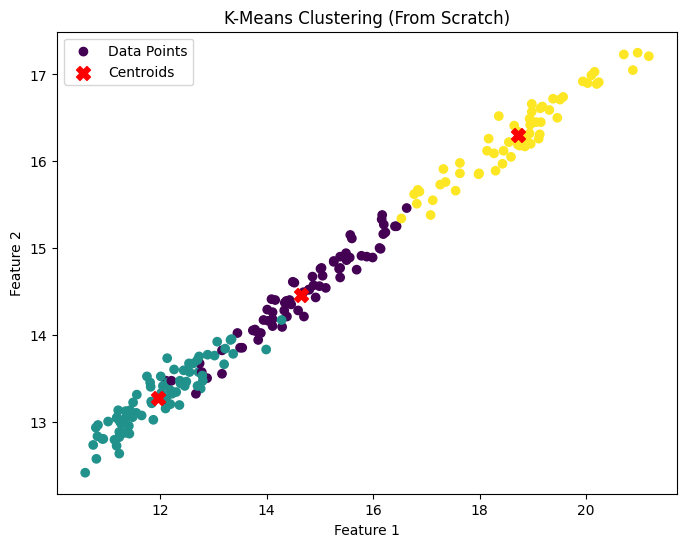

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=cluster_assignments, cmap='viridis', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=100, color='red', label='Centroids')
plt.title('K-Means Clustering (From Scratch)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

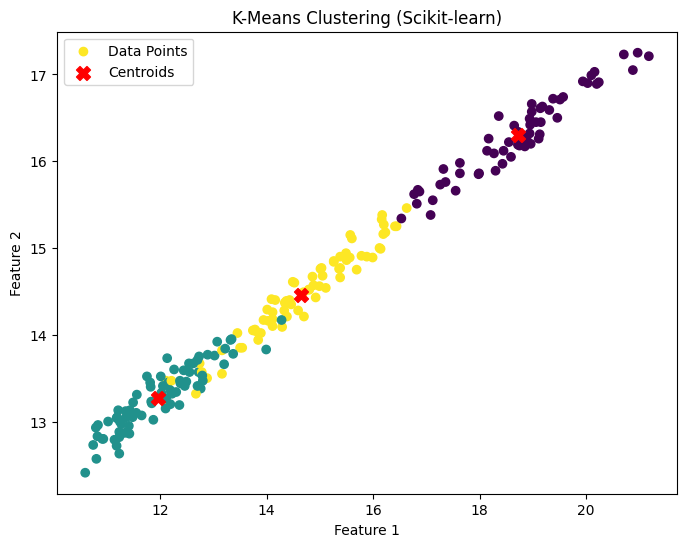

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=skl_cluster_assignments, cmap='viridis', label='Data Points')
plt.scatter(kmeans_skl.cluster_centers_[:, 0], kmeans_skl.cluster_centers_[:, 1], marker='X', s=100, color='red', label='Centroids')
plt.title('K-Means Clustering (Scikit-learn)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()